# Modelo PointTransformer

In [2]:

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
!pip install lazrs laszip laspy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.2/627.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.6/449.6 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 8.3 MB/s eta 0:00:00


In [4]:
import os
import laspy
import numpy as np
import pandas as pd
from skimage.transform import resize

In [5]:
# Pegamos cada talhão dos dados LiDAR coletados
laz_files = sorted([
    f for f in os.listdir("/content/drive/MyDrive/IoT/Dados/SaoManuel/Talhoes/SaoManuel_LIDAR")
    if f.endswith(".laz")
])

print(laz_files)

['SaoManuelTotal_001.laz', 'SaoManuelTotal_002.laz', 'SaoManuelTotal_004.laz', 'SaoManuelTotal_005.laz', 'SaoManuelTotal_006.laz', 'SaoManuelTotal_007.laz']


In [6]:
# Criamos listas para armazenar os pontos, o valor real da altura, os IDs de cada parcela dentro dos talhões e os IDs dos talhões
X_points = []
y_dap = []
parcelas_ids = []
talhoes_ids = []

In [7]:
import geopandas as gpd

gdf = gpd.read_file(
    "/content/drive/MyDrive/IoT/Dados/SaoManuel/shapes/Parcelas/parcelas.shp"
)

gdf["talhao"] = (
    gdf["talhao"]
    .astype(str)
    .str.zfill(3)
)

gdf["parcela"] = (
    gdf["parcela"]
    .astype(str)
    .str.zfill(3)
)

print(gdf.head())

print(gdf["talhao"].unique())

   id     elev parcela talhao     Fazenda        Especie Mat_gen  \
0   1  738.637     001    001  São Manuel  Eucalyptus sp    I144   
1   2  739.195     002    001  São Manuel  Eucalyptus sp    I144   
2   3  774.722     003    003  São Manuel           None    None   
3   4  781.896     004    004  São Manuel  Eucalyptus sp    None   
4   5  776.755     005    004  São Manuel  Eucalyptus sp    None   

                                   geometry  
0  POINT Z (749049.463 7480009.299 738.637)  
1   POINT Z (748983.36 7480013.776 739.195)  
2  POINT Z (748849.993 7479561.952 774.722)  
3  POINT Z (748836.068 7479441.914 781.896)  
4  POINT Z (748827.399 7479324.807 776.755)  
['001' '003' '004' '002' '005' '008' '006' '007']


In [8]:
# Utilizamos 2048 pontos e essa função garante que a seed seja fixa, a fim de garantir a reprodutibilidade da proposta.
def sample_points(points, n_points=2048, seed=42):
    rng = np.random.default_rng(seed)
    if len(points) >= n_points:
        idx = rng.choice(
            len(points),
            n_points,
            replace=False
        )
    else:
        idx = rng.choice(
            len(points),
            n_points,
            replace=True
        )
    return points[idx]

In [9]:
# Essa função realiza a normação dos pontos pelo centroide e calculando a distância com max_dist possibilita que os pontos fiquem mais homogêneos para calculo do DAP
def normalize_points(points):

    centroid = np.mean(points, axis=0)
    points = points - centroid
    max_dist = np.max(np.sqrt(np.sum(points**2, axis=1)))
    points = points / max_dist
    return points

In [10]:
# Abrimos o DAP real medido em campo para cada parcela
df = pd.read_csv(
    "/content/drive/MyDrive/IoT/Dados/SaoManuel/SaoManuelTotal_08022025_plot_metric.csv"
)

df["parcela"] = (
    df["parcela"]
    .astype(str)
    .str.zfill(3)
)

print(df[["parcela", "D_cm"]].head())

  parcela  D_cm
0     001  17.6
1     002  16.8
2     004  12.9
3     005  13.8
4     006  13.8


In [11]:
X_points = []
y_dap = []

for laz_file in laz_files:
    print("Processando dados LiDAR:", laz_file)

    talhao = laz_file.split("_")[-1].replace(".laz","")

    las_path = os.path.join(
        "/content/drive/MyDrive/IoT/Dados/SaoManuel/Talhoes/SaoManuel_LIDAR",
        laz_file
    )

    las = laspy.read(las_path)

    x_lidar = np.array(las.x)
    y_lidar = np.array(las.y)
    z_lidar = np.array(las.z)

    points_all = np.vstack(
        (x_lidar, y_lidar, z_lidar)
    ).transpose()

    gdf_talhao = gdf[
        gdf["talhao"] == talhao
    ]

    print("Parcelas:", len(gdf_talhao))

    for idx, row in gdf_talhao.iterrows():

        geom = row.geometry

        cx = geom.x
        cy = geom.y

        radius = 11.28

        dist = np.sqrt(
            (x_lidar - cx)**2 +
            (y_lidar - cy)**2
        )

        mask = dist <= radius

        crop = points_all[mask]

        if len(crop) < 500:
            continue

        crop = sample_points(
            crop,
            n_points=2048,
            seed=42
        )

        crop = normalize_points(crop)

        parcela = str(
            row["parcela"]
        ).zfill(3)

        dap_row = df[
            df["parcela"] == parcela
        ]

        if len(dap_row) == 0:
            continue

        dap = dap_row["D_cm"].values[0]

        X_points.append(crop)

        y_dap.append(dap)

        print(
            f"Parcela {parcela}"
            f" - pontos {crop.shape}"
            f" DAP = {dap}"
        )

Processando dados LiDAR: SaoManuelTotal_001.laz
Parcelas: 2
Parcela 001 - pontos (2048, 3) DAP = 17.6
Parcela 002 - pontos (2048, 3) DAP = 16.8
Processando dados LiDAR: SaoManuelTotal_002.laz
Parcelas: 2
Parcela 006 - pontos (2048, 3) DAP = 13.8
Parcela 007 - pontos (2048, 3) DAP = 16.0
Processando dados LiDAR: SaoManuelTotal_004.laz
Parcelas: 2
Parcela 004 - pontos (2048, 3) DAP = 12.9
Parcela 005 - pontos (2048, 3) DAP = 13.8
Processando dados LiDAR: SaoManuelTotal_005.laz
Parcelas: 2
Parcela 008 - pontos (2048, 3) DAP = 17.6
Parcela 009 - pontos (2048, 3) DAP = 16.7
Processando dados LiDAR: SaoManuelTotal_006.laz
Parcelas: 3
Parcela 010 - pontos (2048, 3) DAP = 17.8
Parcela 011 - pontos (2048, 3) DAP = 17.0
Parcela 012 - pontos (2048, 3) DAP = 17.4
Processando dados LiDAR: SaoManuelTotal_007.laz
Parcelas: 2
Parcela 013 - pontos (2048, 3) DAP = 17.4
Parcela 014 - pontos (2048, 3) DAP = 20.4


In [12]:
X_points = np.array(X_points)
y_dap = np.array(y_dap)

print(X_points.shape)
print(y_dap.shape)

(13, 2048, 3)
(13,)


In [13]:
X_points = np.array(X_points)
y_dap = np.array(y_dap)

In [14]:
print(X_points.shape)
print(y_dap.shape)

(13, 2048, 3)
(13,)


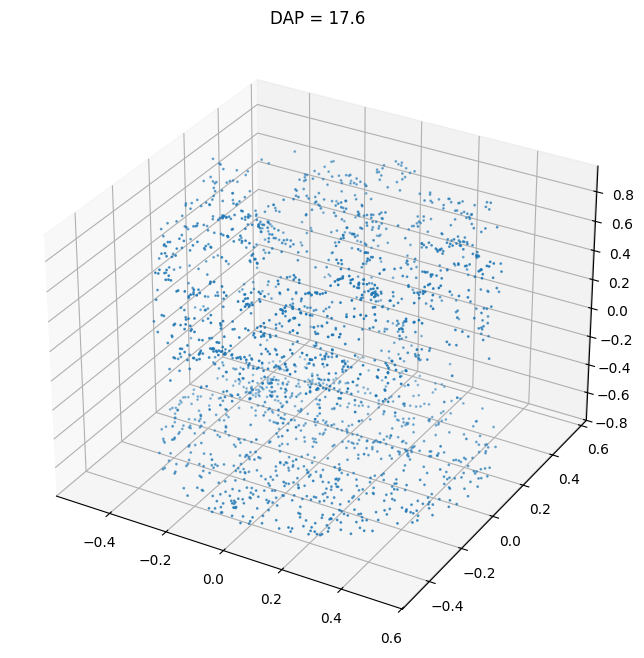

In [15]:
import matplotlib.pyplot as plt
# Plotamos uma parcela para mostrar a quantidade de pontos
sample = X_points[0]
fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(
    111,
    projection='3d'
)

ax.scatter(
    sample[:,0],
    sample[:,1],
    sample[:,2],
    s=1
)

plt.title(
    f"DAP = {y_dap[0]}"
)

plt.show()

In [ ]:
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = list(
    kf.split(X_points)
)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
# Modelo point transformer com uma camada de embedding, seguida de atencao, FFN e regressão.
class PointTransformerRegressor(nn.Module):

    def __init__(self):
        super().__init__()
        self.embedding = nn.Sequential(nn.Linear(3, 64), nn.ReLU(), nn.Linear(64, 128))
        self.attention = nn.MultiheadAttention(embed_dim=128, num_heads=4, batch_first=True)
        self.ffn = nn.Sequential(nn.Linear(128, 256), nn.ReLU(), nn.Linear(256, 128))
        self.regressor = nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 1))

    def forward(self, x):
        x = self.embedding(x)
        attn_output, _ = self.attention(x,x,x)
        x = x + attn_output
        ffn_output = self.ffn(x)
        x = x + ffn_output

        # pooling global

        x = torch.mean(x, dim=1)
        x = self.regressor(x)

        return x

In [ ]:
import time
import psutil
import os
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

import matplotlib.pyplot as plt

In [19]:
results = []
all_targets = []
all_predictions = []
all_fold_ids = []



FOLD 1
MAE=0.886 RMSE=0.902 Pearson r=0.733


FOLD 2
MAE=1.958 RMSE=1.969 Pearson r=0.844


FOLD 3
MAE=2.595 RMSE=3.039 Pearson r=0.756


FOLD 4
MAE=1.619 RMSE=1.832 Pearson r=-1.000


FOLD 5
MAE=1.196 RMSE=1.405 Pearson r=-1.000

CORRELAÇÃO DE PEARSON GLOBAL
Pearson r = 0.1903


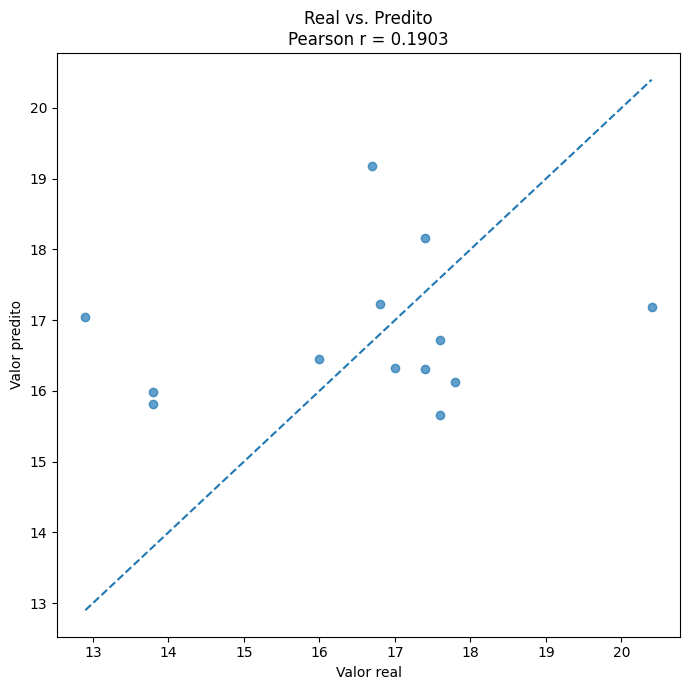

In [ ]:
# Para cada fold, vamos avaliar os resultados por 50 épocas
for fold, (train_idx, test_idx) in enumerate(folds):

    print("\n")
    print(f"FOLD {fold+1}")

    X_train = X_points[train_idx]
    X_test = X_points[test_idx]

    y_train = y_dap[train_idx]
    y_test = y_dap[test_idx]

    X_train = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    X_test = torch.tensor(
        X_test,
        dtype=torch.float32
    )

    y_train = torch.tensor(
        y_train,
        dtype=torch.float32
    ).view(-1, 1)

    y_test = torch.tensor(
        y_test,
        dtype=torch.float32
    ).view(-1, 1)

    train_dataset = TensorDataset(
        X_train,
        y_train
    )

    test_dataset = TensorDataset(
        X_test,
        y_test
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=2,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=2,
        shuffle=False
    )

    model = PointTransformerRegressor()
    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    start_train = time.time()

    train_losses = []
    num_epochs = 50

    for epoch in range(num_epochs):

        model.train()
        epoch_loss = 0

        for points, targets_batch in train_loader:

            optimizer.zero_grad()

            outputs = model(points)

            loss = criterion(
                outputs,
                targets_batch
            )

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = (
            epoch_loss /
            len(train_loader)
        )

        train_losses.append(avg_loss)

    end_train = time.time()

    training_time = end_train - start_train

    predictions = []
    targets = []

    start_inf = time.time()

    model.eval()

    with torch.no_grad():

        for points, labels in test_loader:

            outputs = model(points)

            predictions.extend(
                outputs.cpu().numpy().flatten()
            )

            targets.extend(
                labels.cpu().numpy().flatten()
            )

    end_inf = time.time()

    total_inf_time = end_inf - start_inf

    targets_array = np.array(targets)
    predictions_array = np.array(predictions)

    latency = total_inf_time / len(test_dataset)

    throughput = len(test_dataset) / total_inf_time

    fps = 1 / latency

    mae = mean_absolute_error(
        targets_array,
        predictions_array
    )

    rmse = np.sqrt(
        mean_squared_error(
            targets_array,
            predictions_array
        )
    )

    mask = targets_array != 0

    mape = np.mean(
        np.abs(
            (targets_array[mask] - predictions_array[mask])
            / targets_array[mask]
        )
    ) * 100

    bias = np.mean(
        predictions_array - targets_array
    )

    rrmse = (
        rmse /
        np.mean(targets_array)
    ) * 100

    pearson_r = np.corrcoef(
        targets_array,
        predictions_array
    )[0, 1]

    process = psutil.Process(os.getpid())

    memory_mb = (
        process.memory_info().rss /
        1024**2
    )

    total_params = sum(
        p.numel()
        for p in model.parameters()
    )

    all_targets.extend(targets)
    all_predictions.extend(predictions)
    all_fold_ids.extend(
        [fold + 1] * len(targets)
    )

    results.append({

        "fold": fold + 1,

        "mae": mae,

        "rmse": rmse,

        "mape": mape,

        "bias": bias,

        "rrmse": rrmse,

        "pearson_r": pearson_r,

        "latency": latency,

        "throughput": throughput,

        "fps": fps,

        "memory_mb": memory_mb,

        "params": total_params,

        "training_time": training_time

    })

    print(
        f"MAE={mae:.3f} "
        f"RMSE={rmse:.3f} "
        f"Pearson r={pearson_r:.3f}"
    )

all_targets_array = np.array(all_targets)
all_predictions_array = np.array(all_predictions)

# Correlação de Pearson global
pearson_global = np.corrcoef(
    all_targets_array,
    all_predictions_array
)[0, 1]

print("\n")
print("CORRELAÇÃO DE PEARSON GLOBAL")
print(f"Pearson r = {pearson_global:.4f}")

plt.figure(figsize=(7, 7))

plt.scatter(
    all_targets_array,
    all_predictions_array,
    alpha=0.7
)

min_value = min(
    all_targets_array.min(),
    all_predictions_array.min()
)

max_value = max(
    all_targets_array.max(),
    all_predictions_array.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Valor real")
plt.ylabel("Valor predito")

plt.title(
    f"Real vs. Predito\nPearson r = {pearson_global:.4f}"
)

plt.tight_layout()
plt.show()

In [22]:
results_df = pd.DataFrame(results)

display(results_df)

,fold,mae,rmse,mape,bias,rrmse,pearson_r,latency,throughput,fps,memory_mb,params,training_time
0,1,0.886226,0.902332,5.104488,-0.886226,5.205763,0.733101,0.141603,7.061982,7.061982,1444.328125,148865,219.922218
1,2,1.957515,1.968662,13.274397,0.839248,13.008780,0.844252,0.197241,5.069948,5.069948,1444.328125,148865,219.081690
2,3,2.595330,3.039042,16.810053,0.452226,18.197855,0.756277,0.149175,6.703532,6.703532,1431.562500,148865,234.069928
3,4,1.618734,1.832193,9.601422,1.618734,10.745998,-1.000000,0.209986,4.762215,4.762215,1431.562500,148865,246.512673
4,5,1.195831,1.405067,6.924647,-0.737700,8.363494,-1.000000,0.207680,4.815089,4.815089,1415.562500,148865,256.304141


In [23]:
summary = pd.DataFrame({

    "Media":
        results_df.mean(
            numeric_only=True
        ),

    "Std":
        results_df.std(
            numeric_only=True
        )
})

display(summary)

,Media,Std
fold,3.000000,1.581139
mae,1.650727,0.666860
rmse,1.829459,0.794064
mape,10.343001,4.745865
bias,0.257257,1.063936
rrmse,11.104378,4.908633
pearson_r,0.066726,0.974665
latency,0.181137,0.033093
throughput,5.682553,1.109056
fps,5.682553,1.109056


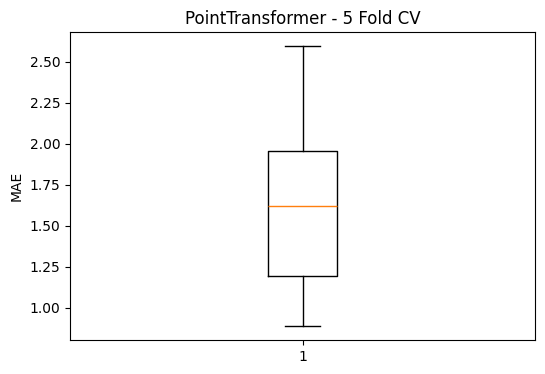

In [24]:
plt.figure(figsize=(6,4))
plt.boxplot(results_df["mae"])
plt.ylabel("MAE")
plt.title("PointTransformer - 5 Fold CV")
plt.show()

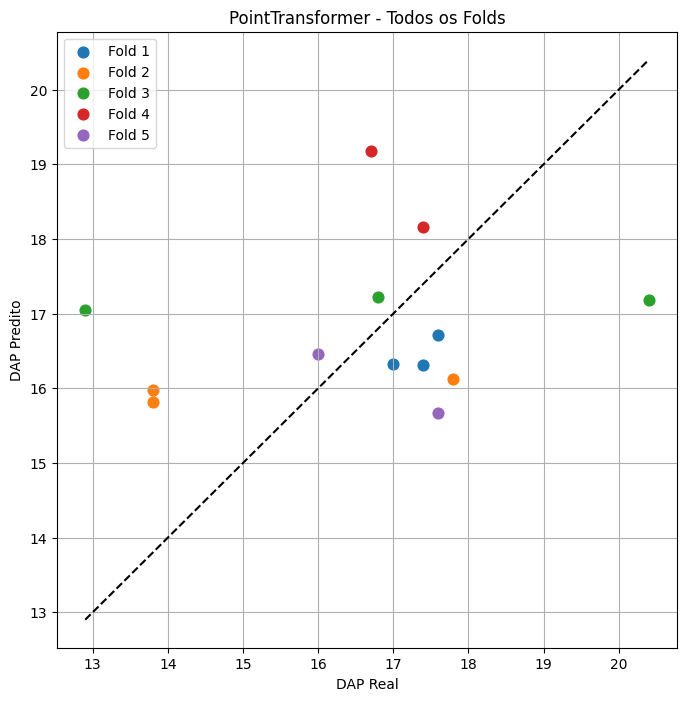

In [25]:
plt.figure(figsize=(8,8))

for fold_id in sorted(set(all_fold_ids)):

    idx = (
        np.array(all_fold_ids)
        ==
        fold_id
    )

    plt.scatter(
        np.array(all_targets)[idx],
        np.array(all_predictions)[idx],
        s=60,
        label=f"Fold {fold_id}"
    )

mn = min(all_targets)
mx = max(all_targets)

plt.plot(
    [mn,mx],
    [mn,mx],
    'k--'
)

plt.xlabel("DAP Real")
plt.ylabel("DAP Predito")
plt.title("PointTransformer - Todos os Folds")
plt.legend()
plt.grid()
plt.show()

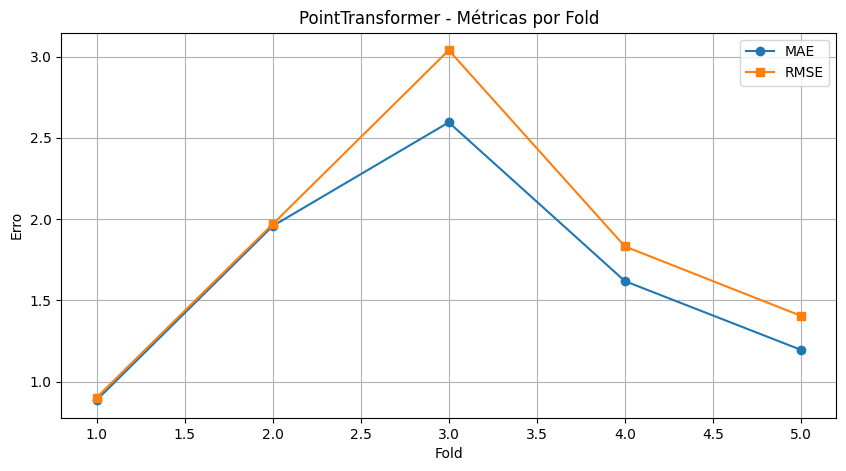

In [26]:
plt.figure(figsize=(10,5))

plt.plot(
    results_df["fold"],
    results_df["mae"],
    marker="o",
    label="MAE"
)

plt.plot(
    results_df["fold"],
    results_df["rmse"],
    marker="s",
    label="RMSE"
)

plt.xlabel("Fold")
plt.ylabel("Erro")
plt.title("PointTransformer - Métricas por Fold")

plt.legend()
plt.grid()
plt.show()